<a href="https://colab.research.google.com/github/fitridianamusa/Artikel-ADW-Kelompok-8/blob/main/TUGAS_ARIMA_HARGA_TELUR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Time Series - Peramalan Harga Telur Semarang menggunakan ARIMA

**Tahapan:**
1. Import & eksplorasi data (EDA)
2. Split data train-test , sebelum semua tahap identifikasi model
3. Uji stasioneritas (ADF Test) → dilakukan pada data train
4. Analisis komponen musiman (decomposition + uji formal), dilakukan pada data train
5. Differencing (jika data belum stasioner),dilakukan pada data train
6. Identifikasi order (p, d, q) via ACF/PACF & `auto_arima` (termasuk versi musiman/SARIMA), dilakukan pada data train.
7. Estimasi/fit model ARIMA pada data train.
8. Evaluasi model pada data test (MAE, RMSE, MAPE).
9. Diagnostik residual model.
10. Forecast/peramalan periode ke depan (refit pakai seluruh data).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline

## 1. Import & Eksplorasi Data (EDA)

In [ ]:
import pandas as pd

# URL file Excel dari GitHub
url = "https://raw.githubusercontent.com/rahminurulainunfitrah/Praktikum-Analisis-Deret-Waktu/main/harga_telur_semarang.xlsx"

# Membaca file Excel
df = pd.read_excel(url)

# Membersihkan nama kolom
df.columns = df.columns.str.strip().str.lower()

# Mengubah kolom periode menjadi format tanggal
df["periode"] = pd.to_datetime(df["periode"])

# Mengurutkan data berdasarkan periode
df = df.sort_values("periode").reset_index(drop=True)

# Menjadikan periode sebagai index
df = df.set_index("periode")

# Mengubah frekuensi data menjadi harian
df = df.asfreq("D")

# Interpolasi data yang hilang
df["semarang"] = df["semarang"].interpolate()

# Menampilkan jumlah observasi
print("Jumlah observasi:", len(df))

# Menampilkan data
print("\nData:")
display(df)

# Menampilkan statistik deskriptif
print("\nStatistik deskriptif:")
display(df.describe())

Jumlah observasi: 364

Data:


,semarang
periode,
2023-01-02,27900.00000
2023-01-03,27900.00000
2023-01-04,28000.00000
2023-01-05,28000.00000
2023-01-06,28000.00000
...,...
2023-12-27,26800.00000
2023-12-28,26700.00000
2023-12-29,26700.00000



Statistik deskriptif:


,semarang
count,364.000000
mean,27998.644626
std,1909.367633
min,23572.071940
25%,26700.000000
50%,27550.000000
75%,29800.000000
max,31800.000000


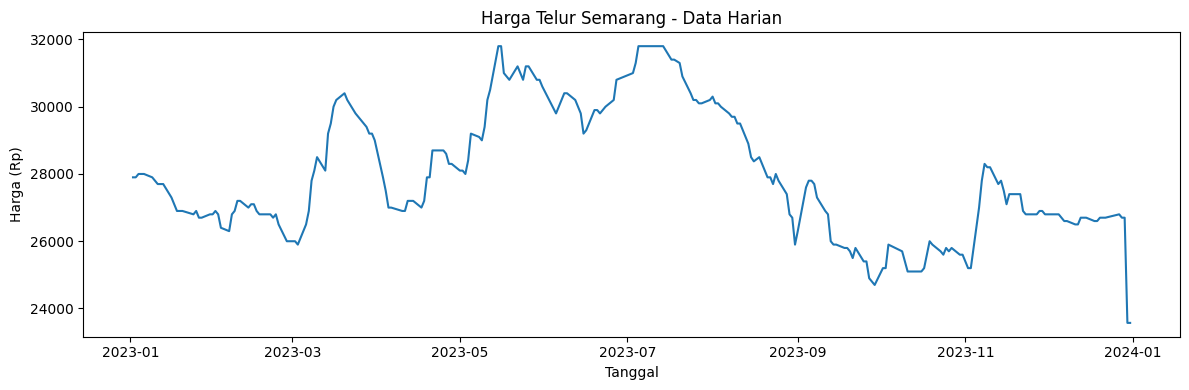

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["semarang"])
plt.title("Harga Telur Semarang - Data Harian")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.tight_layout()
plt.show()

## 2. Split Data Train-Test

In [ ]:
n_test = 61   # 61 hari terakhir dipakai sebagai data uji, sisanya untuk data latih
train = df["semarang"].iloc[:-n_test]
test = df["semarang"].iloc[-n_test:]

print(f"Jumlah data train : {len(train)}")
print(f"Jumlah data test   : {len(test)}")


Jumlah data train : 303
Jumlah data test   : 61


## Uji Stasioneritas Data

### 1. Uji Stasioneritas Data dalam Nilaitengah

In [ ]:
# Uji Stasioneritas Data dalam Nilaitengah
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

train = df["semarang"].iloc[:-n_test]
adfuller(train)[1]

/tmp/ipykernel_908/2440028415.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adfuller(train)[1]


0.5121996806995558

### 2. Cek Stasioneritas dalam Ragam

In [ ]:
train = df["semarang"].iloc[:-n_test]
train.min()

24700.0

In [ ]:
# Mencari lambda Box-Cox
from scipy.stats import boxcox, boxcox_llf

train = df["semarang"].iloc[:-n_test]
data_boxcox, lambda_fit, ci = boxcox(
    train,
    alpha=0.05
)

print('Nilai lambda:', lambda_fit)
print('Interval kepercayaan lambda:', ci)

Nilai lambda: -0.5653275195129833
Interval kepercayaan lambda: (-2.3726169676149045, 1.2458020259396623)


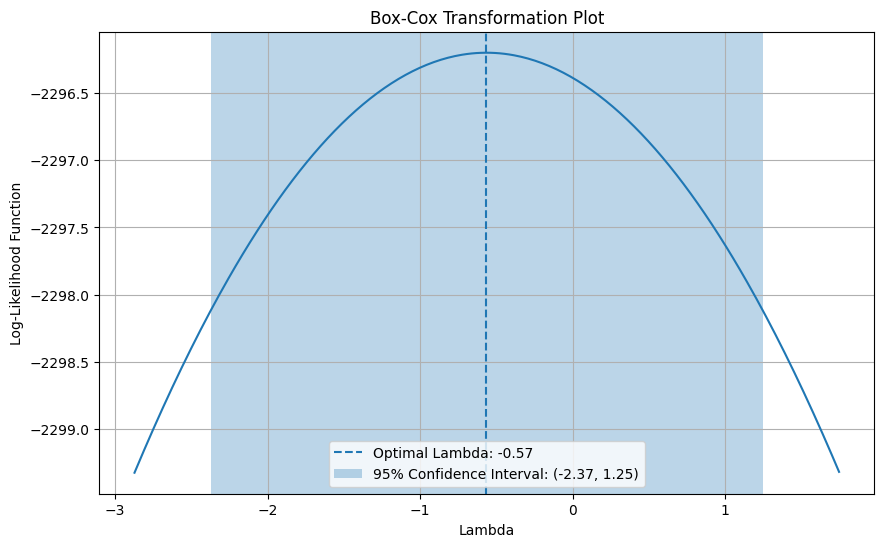

In [ ]:
# Plot Box-Cox likelihood
# Rentang lambda dibuat mencakup lambda optimal dan CI
train = df["semarang"].iloc[:-n_test]
lambdas = np.linspace(ci[0] - 0.5, ci[1] + 0.5, 300)

llf = [
    boxcox_llf(lmbda,train)
    for lmbda in lambdas
]

plt.figure(figsize=(10, 6))

plt.plot(lambdas, llf)

plt.axvline(
    lambda_fit,
    linestyle='--',
    label=f'Optimal Lambda: {lambda_fit:.2f}'
)

plt.axvspan(
    ci[0],
    ci[1],
    alpha=0.3,
    label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})'
)

plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend()
plt.grid(True)

plt.show()

### 3. Proses Differencing

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Data train
train = df["semarang"].iloc[:-n_test]

# Differencing orde 1
train_diff = train.diff().dropna()

# Uji ADF setelah differencing
adf_result = adfuller(train_diff)

print("Hasil Uji ADF Setelah Differencing Orde 1")
print("-----------------------------------------")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.6g}")

Hasil Uji ADF Setelah Differencing Orde 1
-----------------------------------------
ADF Statistic : -8.2884
p-value       : 4.32821e-13


/tmp/ipykernel_908/1271317617.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(train_diff)


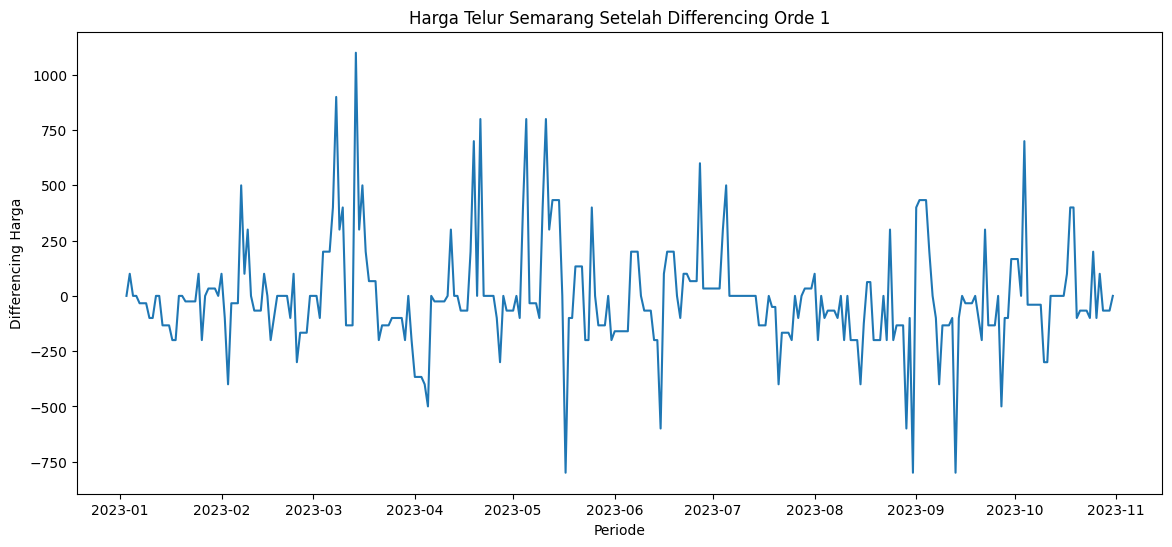

In [ ]:
# Plot Data setelah Differencing Orde 1
plt.figure(figsize=(14, 6))
plt.plot(train_diff)

plt.title('Harga Telur Semarang Setelah Differencing Orde 1')
plt.xlabel('Periode')
plt.ylabel('Differencing Harga')

plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

def acf_pacf_fig(data, both=True, lag=30):
    if both:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        # ACF
        plot_acf(data, lags=lag, ax=axes[0])
        axes[0].set_title("ACF")
        axes[0].set_xlabel("Lag")
        axes[0].set_ylabel("Autocorrelation")

        # PACF
        plot_pacf(data, lags=lag, ax=axes[1], method="ywm")
        axes[1].set_title("PACF")
        axes[1].set_xlabel("Lag")
        axes[1].set_ylabel("Partial Autocorrelation")

        plt.tight_layout()
        plt.show()


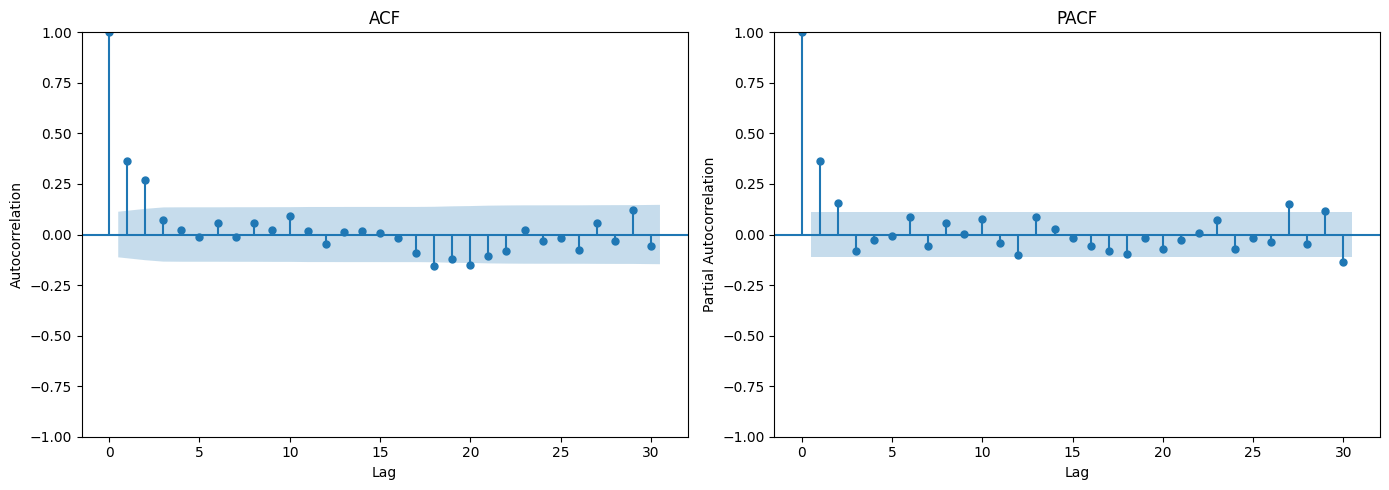

In [ ]:
# Plot ACF dan PACF
acf_pacf_fig(
    train_diff,
    both=True,
    lag=30
)

Karena ACF dan PACF sama-sama menunjukkan cutt off di lag 2, kandidat model yang wajar untuk diuji adalah ARIMA(2,1,2). Tetapi karena ada beberapa spike signifikan kembali pada lag yang lebih tinggi, sebaiknya jangan langsung menyimpulkan \(p=q=2\); gunakan beberapa kandidat seperti ARIMA(2,1,0), ARIMA(0,1,2), dan ARIMA(2,1,2) kemudian bandingkan berdasarkan AIC/BIC dan diagnostik residual.

## 4. Model ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

models = {
    "ARIMA(2,1,0)": ARIMA(train, order=(2,1,0)).fit(),
    "ARIMA(0,1,2)": ARIMA(train, order=(0,1,2)).fit(),
    "ARIMA(2,1,2)": ARIMA(train, order=(2,1,2)).fit()
}

In [ ]:
for name, result in models.items():
    print(
        name,
        " | AIC =", result.aic,
        " | BIC =", result.bic
    )

ARIMA(2,1,0)  | AIC = 4116.169816807183  | BIC = 4127.301097859308
ARIMA(0,1,2)  | AIC = 4115.613983352071  | BIC = 4126.745264404196
ARIMA(2,1,2)  | AIC = 4117.8031980964815  | BIC = 4136.3553331833555


In [ ]:
print(models["ARIMA(2,1,0)"].summary())
print(models["ARIMA(0,1,2)"].summary())

                               SARIMAX Results                                
Dep. Variable:               semarang   No. Observations:                  303
Model:                 ARIMA(2, 1, 0)   Log Likelihood               -2055.085
Date:                Fri, 18 Sep 2026   AIC                           4116.170
Time:                        03:56:07   BIC                           4127.301
Sample:                    01-02-2023   HQIC                          4120.624
                         - 10-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2676      0.040      6.770      0.000       0.190       0.345
ar.L2          0.1490      0.044      3.390      0.001       0.063       0.235
sigma2      4.723e+04   2053.058     23.004      0.0

In [ ]:
n_test = 61  # 61 hari terakhir dipakai sebagai data uji

train = df["semarang"].iloc[:-n_test]
test = df["semarang"].iloc[-n_test:]

from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

# forecast data testing
forecast = {}

for name, model in models.items():
    forecast[name] = model.forecast(steps=len(test))

# MAPE
hasil_mape = []

for name, pred in forecast.items():
    mape = mean_absolute_percentage_error(test, pred) * 100

    hasil_mape.append({
        "Model": name,
        "MAPE (%)": mape
    })

# Tabel hasil
hasil_mape = pd.DataFrame(hasil_mape)

print(hasil_mape)

          Model  MAPE (%)
0  ARIMA(2,1,0)  5.020628
1  ARIMA(0,1,2)  4.952086
2  ARIMA(2,1,2)  4.952428


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Seluruh data yang tersedia (train + test)
data_full = df["semarang"]

# Fit ulang model menggunakan seluruh data
models_final = {
    "ARIMA(0,1,2)": ARIMA(data_full, order=(0,1,2)).fit(),

}

In [ ]:
forecast_7 = {}

for name, model in models_final.items():
    forecast_7[name] = model.forecast(steps=7)

In [ ]:
hasil_forecast_7 = pd.DataFrame(forecast_7)

print(hasil_forecast_7)

            ARIMA(2,1,0)  ARIMA(0,1,2)  ARIMA(2,1,2)
2024-01-01  23011.019230  22941.669518  22923.015064
2024-01-02  22910.079057  23067.787225  22862.951502
2024-01-03  22791.283345  23067.787225  22951.667375
2024-01-04  22751.805041  23067.787225  22997.069086
2024-01-05  22723.394172  23067.787225  22999.615575
2024-01-06  22711.201536  23067.787225  22992.756972
2024-01-07  22703.911910  23067.787225  22989.610163


In [ ]:
model_final = ARIMA(df["semarang"], order=(0,1,2)).fit()

forecast_7 = model_final.forecast(steps=7)

print(forecast_7)

2024-01-01    22941.669518
2024-01-02    23067.787225
2024-01-03    23067.787225
2024-01-04    23067.787225
2024-01-05    23067.787225
2024-01-06    23067.787225
2024-01-07    23067.787225
Freq: D, Name: predicted_mean, dtype: float64


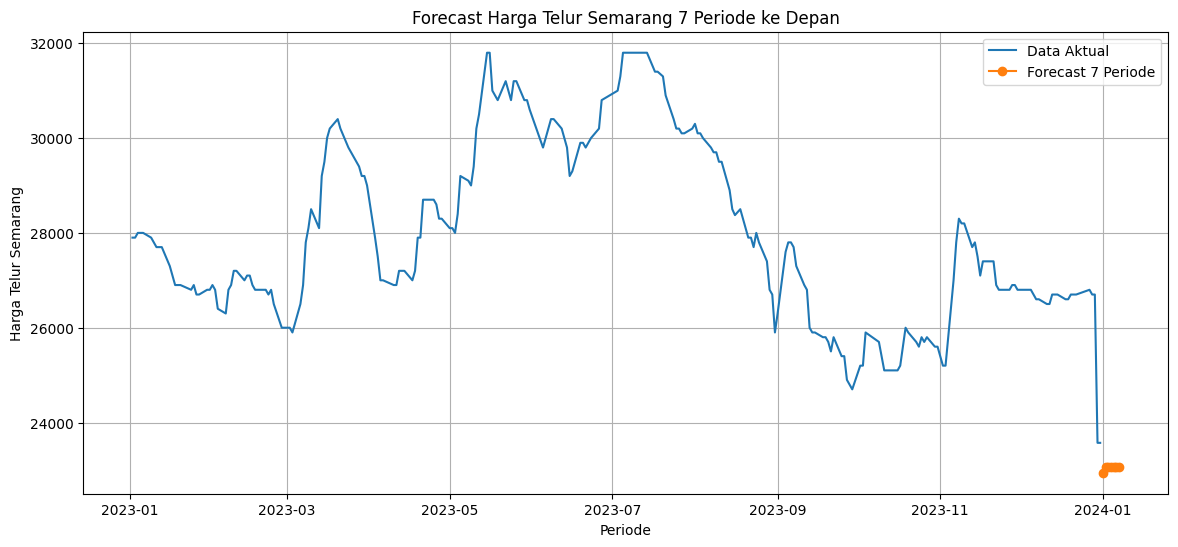

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df["semarang"].index,
    df["semarang"],
    label="Data Aktual"
)

plt.plot(
    forecast_7.index,
    forecast_7,
    marker="o",
    label="Forecast 7 Periode"
)

plt.title("Forecast Harga Telur Semarang 7 Periode ke Depan")
plt.xlabel("Periode")
plt.ylabel("Harga Telur Semarang")
plt.legend()
plt.grid(True)

plt.show()